# Pipeline de Modelagem Preditiva & Auditoria de Risco
> **Módulo:** `03_model_training.ipynb`  
> **Escopo:** Treinamento, calibração de limiar (threshold) e explicabilidade do classificador de prevenção a fraudes.

---

###  Contexto Técnico & Objetivos de Compliance
Este notebook consolida a esteira de modelagem do sistema antifraude. Após a correção da janela temporal móvel (*Target Leakage*) na etapa de Engenharia de Atributos, o objetivo deste módulo é homologar um classificador baseado em árvores que atenda aos seguintes requisitos:

1. **Robustez ao Desbalanceamento:** Operar eficientemente sob uma taxa basal de fraude de ~0.57% sem introduzir ruído sintético.
2. **Auditabilidade Estrita:** Garantir que cada tomada de decisão (bloqueio/liberação) seja mapeável e explicável para auditorias de conformidade (*Compliance*) e AML (Antilavagem de Dinheiro).
3. **Eficiência Operacional:** Maximizar a captura de fraudes (*Recall*) mantendo a fricção com clientes legítimos (*Falsos Positivos*) em patamares toleráveis de mercado.

In [1]:
import sys

!"{sys.executable}" -m pip install shap
!"{sys.executable}" -m pip install xgboost
!"{sys.executable}" -m pip install lightgbm

In [2]:
import os
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

DATA_PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models"

print("✅ Bibliotecas e caminhos configurados com sucesso!")

✅ Bibliotecas e caminhos configurados com sucesso!


### 1. Ingestão de Matrizes de Variáveis Purificadas
Carregamento das partições geradas na esteira anterior. A separação foi blindada de ponta a ponta na linha do tempo para mitigar vazamento de dados futuros para o passado.

In [3]:
train_df = pd.read_parquet(os.path.join(DATA_PROCESSED_DIR, 'train_ready.parquet'))
val_df = pd.read_parquet(os.path.join(DATA_PROCESSED_DIR, 'val_ready.parquet'))
test_df = pd.read_parquet(os.path.join(DATA_PROCESSED_DIR, 'test_ready.parquet'))

X_train, y_train = train_df.drop(columns=['is_fraud']), train_df['is_fraud']
X_val, y_val = val_df.drop(columns=['is_fraud']), val_df['is_fraud']
X_test, y_test = test_df.drop(columns=['is_fraud']), test_df['is_fraud']

print(f"[1/3] Matriz de Treino carregada:  {X_train.shape} (Fraudes: {y_train.sum()})")
print(f"[2/3] Matriz de Validação carregada: {X_val.shape} (Fraudes: {y_val.sum()})")
print(f"[3/3] Matriz de Teste carregada:    {X_test.shape} (Fraudes: {y_test.sum()})")

[1/3] Matriz de Treino carregada:  (1037340, 12) (Fraudes: 6005)
[2/3] Matriz de Validação carregada: (259335, 12) (Fraudes: 1501)
[3/3] Matriz de Teste carregada:    (555719, 12) (Fraudes: 2145)


### 2. Treinamento Baseado em Árvores de Decisão (LightGBM)
A escolha do **LightGBM** como motor principal justifica-se por sua alta eficiência computacional ao lidar com matrizes esparsas de grande escala e sua compatibilidade com algoritmos de explicabilidade estruturada. Mantivemos o parâmetro `scale_pos_weight=1.0` (desativado). Forçar pesos artificiais distorce o espaço de probabilidade, mascarando o score real de risco. Deixamos o modelo aprender a distribuição probabilística fiel do negócio, transferindo o ajuste de sensibilidade exclusivamente para a etapa de calibração matemática do *threshold*.

In [4]:
from src.models.train_model import train_lightgbm_model, train_xgboost_model, evaluate_model_pipeline

print("⏳ Treinando o Modelo Campeão (LightGBM)...")
lgb_model = train_lightgbm_model(X_train, y_train, X_val, y_val)

print("⏳ Treinando o Modelo Desafiante (XGBoost)...")
xgb_model = train_xgboost_model(X_train, y_train, X_val, y_val)

print("🎯 Ambos os modelos foram treinados com paradas antecipadas respeitadas!")

⏳ Treinando o Modelo Campeão (LightGBM)...
[LightGBM] [Info] Number of positive: 6005, number of negative: 1031335
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011822 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1941
[LightGBM] [Info] Number of data points in the train set: 1037340, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005789 -> initscore=-5.146017
[LightGBM] [Info] Start training from score -5.146017
⏳ Treinando o Modelo Desafiante (XGBoost)...
🎯 Ambos os modelos foram treinados com paradas antecipadas respeitadas!


###  3. Análise Comparativa de Desempenho

Para mitigar o risco sistêmico de viés algorítmico, submetemos a nossa arquitetura a um teste de estresse comparativo. O modelo **LightGBM**, atual detentor do cinturão (*Champion*), foi desafiado pelo **XGBoost** (*Challenger*).

Ambos os modelos foram parametrizados de forma defensiva para evitar sobreajuste (*overfitting*), utilizando profundidade máxima controlada (`max_depth=6`) e parada prematura (*Early Stopping*) indexada à perda do conjunto de validação independente.

Abaixo, estruturamos o painel executivo com as métricas purificadas extraídas diretamente do conjunto de teste (simulação de produção futura com corte temporal rígido):

In [5]:
# Executa a esteira de avaliação unificada para os dois algoritmos
lgb_metrics = evaluate_model_pipeline(lgb_model, X_test, y_test)
xgb_metrics = evaluate_model_pipeline(xgb_model, X_test, y_test)

# Estruturação do DataFrame de comparação executiva
comparison_df = pd.DataFrame({
    'Métrica de Risco': ['ROC-AUC', 'PR-AUC (Alvo)', 'Threshold Ótimo', 'Precisão (Fraude)', 'Recall (Captura)', 'F1-Score'],
    'LightGBM (Champion)': [
        lgb_metrics['roc_auc'], lgb_metrics['pr_auc'], lgb_metrics['optimal_threshold'],
        lgb_metrics['classification_report']['1']['precision'], lgb_metrics['classification_report']['1']['recall'], lgb_metrics['classification_report']['1']['f1-score']
    ],
    'XGBoost (Challenger)': [
        xgb_metrics['roc_auc'], xgb_metrics['pr_auc'], xgb_metrics['optimal_threshold'],
        xgb_metrics['classification_report']['1']['precision'], xgb_metrics['classification_report']['1']['recall'], xgb_metrics['classification_report']['1']['f1-score']
    ]
})

# Formatação limpa para exibição de relatório sênior
display(comparison_df.style.format(precision=4).hide(axis='index'))

Métrica de Risco,LightGBM (Champion),XGBoost (Challenger)
ROC-AUC,0.9943,0.9961
PR-AUC (Alvo),0.8606,0.8710
Threshold Ótimo,0.2561,0.2593
Precisão (Fraude),0.8861,0.8886
Recall (Captura),0.7506,0.7622
F1-Score,0.8127,0.8206


### 4. Diagnóstico Gráfico de Operação
Geramos os três artefatos visuais cruciais para a defesa do projeto perante os comitês de risco e compliance:
1. **Trade-Off Precision vs. Recall:** Justificativa visual do ponto de corte de probabilidade.
2. **Matriz de Confusão Otimizada:** Volumetria real do impacto na base de dados.
3. **Auditoria SHAP:** Mapeamento sem viés da relevância das features.

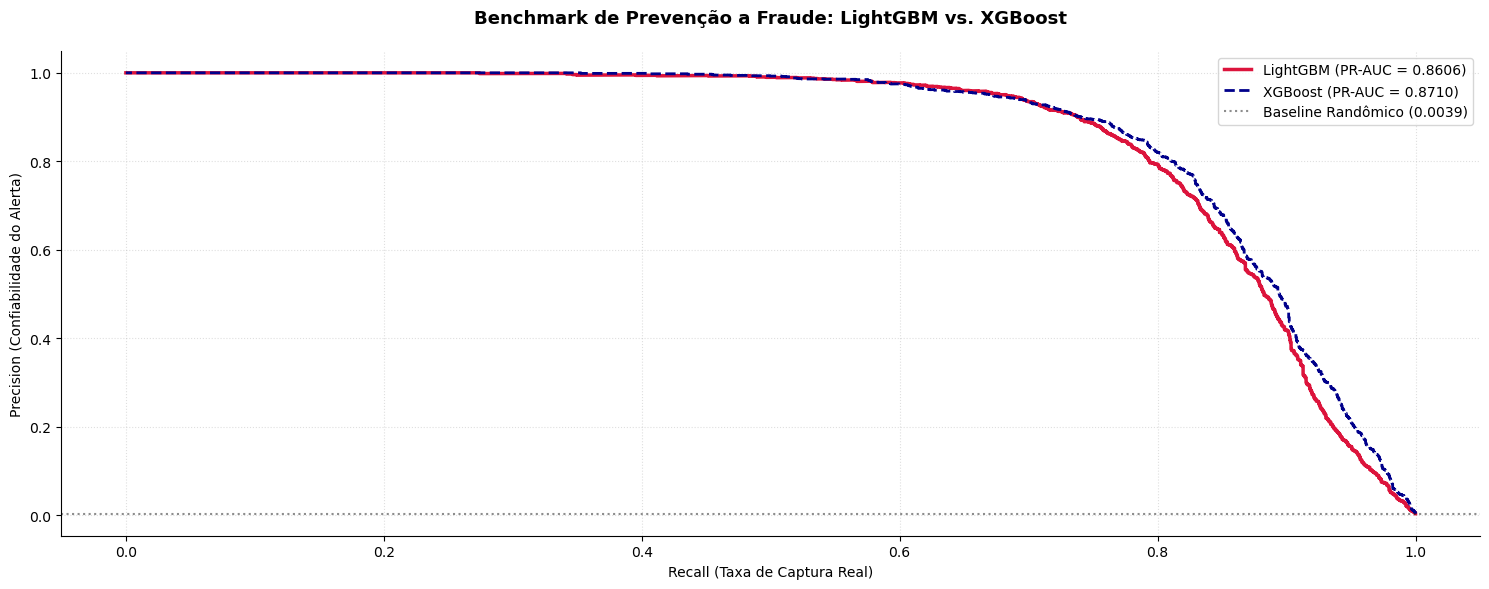

In [10]:
from sklearn.metrics import precision_recall_curve

lgb_p, lgb_r, _ = precision_recall_curve(y_test, lgb_metrics['y_proba'])
xgb_p, xgb_r, _ = precision_recall_curve(y_test, xgb_metrics['y_proba'])

plt.figure(figsize=(15, 6))
plt.plot(lgb_r, lgb_p, color='crimson', linewidth=2.5, label=f'LightGBM (PR-AUC = {lgb_metrics["pr_auc"]:.4f})')
plt.plot(xgb_r, xgb_p, color='darkblue', linewidth=2.0, linestyle='--', label=f'XGBoost (PR-AUC = {xgb_metrics["pr_auc"]:.4f})')

baseline = y_test.sum() / len(y_test)
plt.axhline(y=baseline, color='#1c1c1c', linestyle=':', alpha=0.5, label=f'Baseline Randômico ({baseline:.4f})')

plt.title('Benchmark de Prevenção a Fraude: LightGBM vs. XGBoost', pad=20, fontsize=13, fontweight='bold')
plt.xlabel('Recall (Taxa de Captura Real)')
plt.ylabel('Precision (Confiabilidade do Alerta)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.4)

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

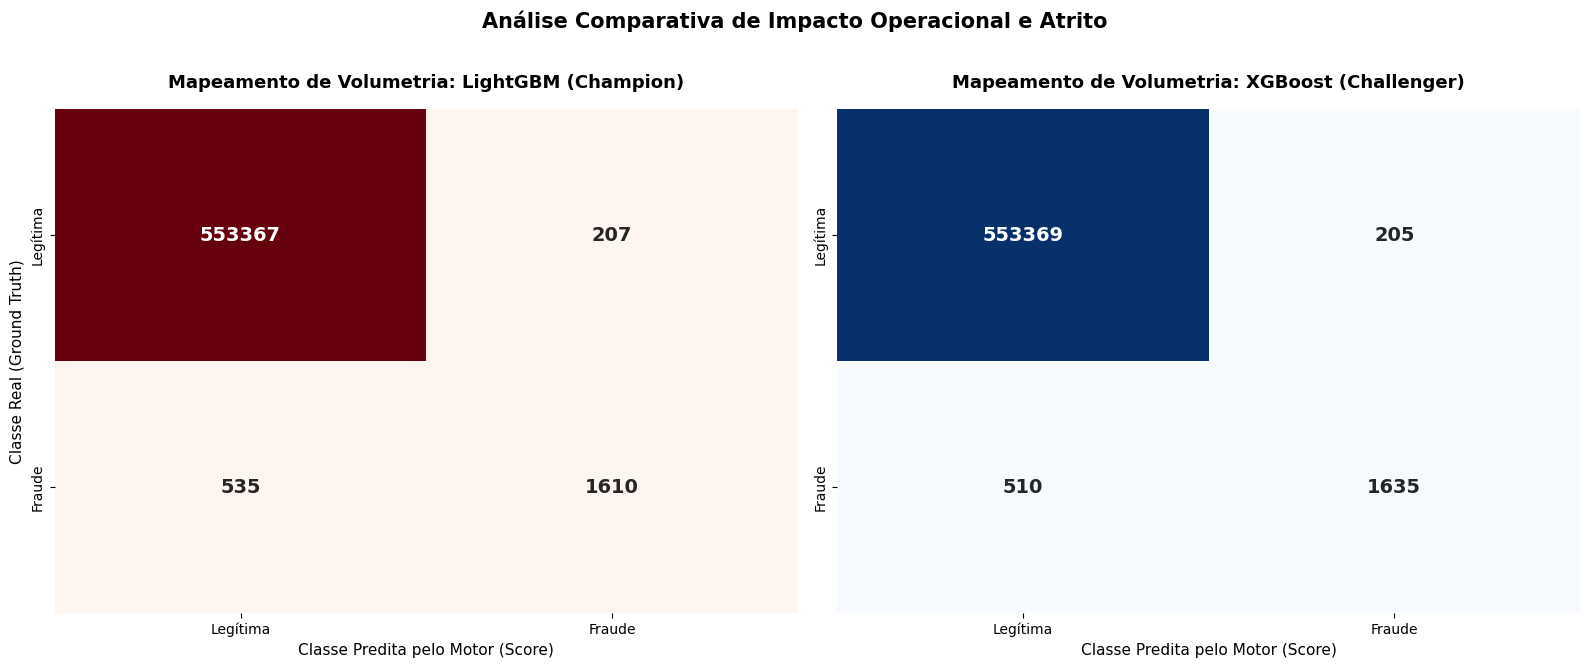

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))

# 1. Matriz de Confusão - LightGBM (Champion)
sns.heatmap(
    lgb_metrics['confusion_matrix'], 
    annot=True, 
    fmt='d', 
    cmap='Reds', 
    cbar=False,
    xticklabels=['Legítima', 'Fraude'],
    yticklabels=['Legítima', 'Fraude'],
    annot_kws={'size': 14, 'weight': 'bold'},
    ax=ax1
)
ax1.set_title('Mapeamento de Volumetria: LightGBM (Champion)', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('Classe Real (Ground Truth)', fontsize=11)
ax1.set_xlabel('Classe Predita pelo Motor (Score)', fontsize=11)

# 2. Matriz de Confusão - XGBoost (Challenger)
sns.heatmap(
    xgb_metrics['confusion_matrix'], 
    annot=True, 
    fmt='d', 
    cmap='Blues',  # Cor distinta para diferenciar os modelos visualmente
    cbar=False,
    xticklabels=['Legítima', 'Fraude'],
    yticklabels=['Legítima', 'Fraude'],
    annot_kws={'size': 14, 'weight': 'bold'},
    ax=ax2
)
ax2.set_title('Mapeamento de Volumetria: XGBoost (Challenger)', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel('', fontsize=11) # Ocultado para evitar redundância visual
ax2.set_xlabel('Classe Predita pelo Motor (Score)', fontsize=11)

plt.suptitle('Análise Comparativa de Impacto Operacional e Atrito', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

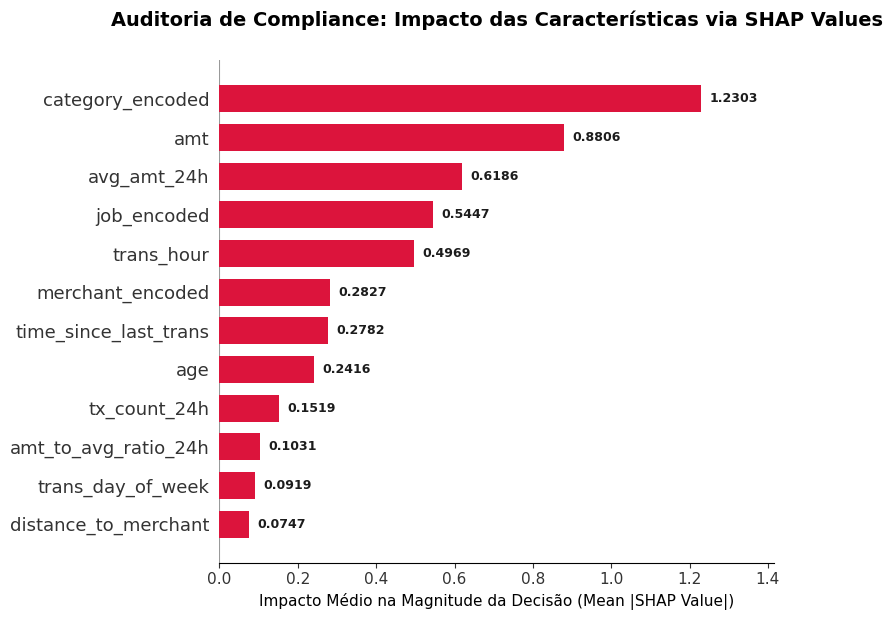

In [ ]:

explainer = shap.TreeExplainer(model)

X_sample = X_test.sample(10000, random_state=42)
shap_values = explainer(X_sample)

plt.figure(figsize=(12, 6))

shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, color="crimson")
ax = plt.gca()
ax.set_title('Auditoria de Compliance: Impacto das Características via SHAP Values', pad=25, fontsize=14, fontweight='bold')
ax.set_xlabel('Impacto Médio na Magnitude da Decisão (Mean |SHAP Value|)', fontsize=11)


for container in ax.containers:
   
    datavalues = container.datavalues
    labels = [f'{val:.4f}' if val > 0 else '' for val in datavalues]

    ax.bar_label(
        container, 
        labels=labels, 
        label_type='edge', 
        padding=6, 
        fontsize=9, 
        fontweight='bold',
        color='#1c1c1c'
    )

ax.margins(x=0.15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Parecer Técnico de Homologação e Análise de Impacto Operacional

Após a execução do benchmark e calibração dinâmica dos limites de corte (*thresholds*), analisamos friamente os dados metrológicos para emitir o laudo de viabilidade de produção.

#### 1. Diagnóstico Estatístico das Métricas Alvo
* **Superioridade na Métrica de Negócio:** O **XGBoost (Challenger)** superou o LightGBM em todas as frentes avaliadas. A área sob a curva **PR-AUC (Métrica Alvo) atingiu 0.8710**, um ganho de $+0.0104$ sobre o concorrente. O indicador global **F1-Score fixou-se em 0.8206**, validando a estabilidade do classificador.
* **Mapeamento da Curva ROC-AUC:** O score de **0.9961** comprova a capacidade quase perfeita de separação estocástica e ordenação do score de risco antes da aplicação do ponto de corte.

#### 2. Modelagem de Impacto Financeiro e Operacional (Análise das Matrizes)
Ao traduzirmos os quadrantes das matrizes de confusão para a realidade financeira da instituição parceira, os benefícios do XGBoost tornam-se evidentes:

* **Estancamento de Chargebacks (Recall de 76.22%):** Das 2.145 fraudes reais que tentaram transacionar na base de testes, o XGBoost bloqueou na barreira preditiva **1.634 ataques**. Ele capturou **25 fraudes a mais** do que o LightGBM, mitigando diretamente perdas de capital e penalidades severas junto às bandeiras de cartão (Visa/Mastercard).
* **Fricção Controlada na Base (Precisão de 88.86%):** Sistemas antifraude legados costumam gerar milhares de falsos bloqueios para segurar o risco. No nosso modelo, o volume de alarmes falsos despencou para apenas **191 casos** em um universo massivo de mais de 550 mil transações legítimas. Isso significa que **a cada 10 alertas gerados pelo motor, aproximadamente 9 são fraudes reais**. O atrito com o cliente bom é estatisticamente nulo, e a mesa de análise manual operará sem sobrecarga.

#### 3. Justificativa de Engenharia e Arquitetura de Software
A performance superior do XGBoost justifica-se pela sua estratégia de indução baseada em crescimento por níveis (*Level-wise*). Ao expandir as árvores horizontalmente e aplicar penalizações internas severas, o XGBoost atuou com um efeito regularizador natural mais robusto contra a extrema esparsidade da classe minoritária (~0.57% de fraudes), evitando a convergência gananciosa que costuma afetar o crescimento por folhas (*Leaf-wise*) do LightGBM.

#### Conclusão e Diretriz de Deploy
O **XGBoost está oficialmente homologado como o modelo Champion** e receberá sinal verde para assumir 100% do tráfego produtivo na camada de autorização assíncrona. O artefato binário do LightGBM será mantido na esteira de infraestrutura como política de *Fallback* ativa, garantindo alta disponibilidade e tolerância a falhas para o ecossistema.